# 07 — PCA + Clustering de Días (Règims Operatius del Campus)

**Objectiu**: identificar règims operatius reals del campus a nivell de **dia** i contrastar-los
amb les etiquetes del calendari acadèmic. Es completen dos analyses complementaris:

| Anàlisi | Unitat | Features | Propòsit |
|---------|--------|----------|----------|
| A. K-Means per OCUPACIÓ | Dia | Perfil horari 24h d'ocupació | Feature del model + validació calendari |
| B. K-Means per CONSUM | Dia | Perfil horari 24h de consum | Anàlisi descriptiu, NO feature del model |
| C. DBSCAN per hores | Hora | Ocupació + Temperatura + Hora | Detecció d'hores anòmales |

**Per què a nivell de dia** (diferència clau respecte a l'enfocament anterior):
- Clusterar *hores individuals* amb `Consumo_kWh` com a feature és circularitat metodològica
  (s'usa el target per predir el target).
- Clusterar *dies sencers* per perfil d'ocupació és defensable: no toca el target.

**Referència**: Wang & Shao (2020) — PCA + K-Means sobre perfils WiFi per règims operatius.

**Figures generades**:
- `pca_per_mes.png` — deriva estacional visible en l'espai PCA
- `pca_per_cluster.png` — agrupació operativa descoberta
- `perfils_horaris_cluster.png` — perfil mitjà de cada règim (**figura més intuïtiva**)
- `crosstab_cluster_calendari.png` — on el calendari "menteix"
- `clustering_ocupacio_vs_consum.png` — comparació dels dos espais latents
- `dbscan_hores_anomales.png` — hores atípiques (sense usar el target)
- `kmeans_interactiu.html` — 3D interactiu per a la presentació oral

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors

DATA_PROCESSED = Path('../data/processed')
DATA_RAW       = Path('../data/raw')
FIGURES        = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETA_CL = ['#5B9BD5', '#70AD47', '#FF8C00', '#C00000']
MESOS_CA  = ['Gen','Feb','Mar','Abr','Mai','Jun',
              'Jul','Ago','Set','Oct','Nov','Des']
print('OK')

c:\Users\jordi\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


OK


In [2]:
# ── Carregar dades ────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PROCESSED / 'dataset_smart_campus_master.csv',
                 parse_dates=['Timestamp'])

# Normalitzar noms de columna per compatibilitat
rename_map = {'personas_total': 'Ocupacion_Simulada', 'temp_c': 'Temperatura'}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# ── [FIX] Eliminar artefacte del simulador: dia 366 = 2025-01-01 ──────────────
# El simulador genera un tick extra (off-by-one) que produeix 24h amb
# ocupació=0 i consum=standby etiquetades erròniament com a 'Classe'.
# Detectat automàticament pel clustering de consum (outlier PC2=-21.66).
n_abans = len(df)
df = df[df['Timestamp'].dt.year == 2024].copy()
print(f'Artefacte eliminat: {n_abans - len(df)} files (2025-01-01)')

# Features temporals
df['fecha'] = df['Timestamp'].dt.date
df['hora']  = df['Timestamp'].dt.hour
df['mes']   = df['Timestamp'].dt.month

# Columna tipus_dia (ja al CSV mergeado)
COL_TIPUS = 'tipus_dia' if 'tipus_dia' in df.columns else 'tipo_dia'

print(f'Dataset: {df.shape[0]:,} hores × {df.shape[1]} columnes')
print(f'Rango: {df["Timestamp"].min().date()} → {df["Timestamp"].max().date()}')
print(f'\nTipus de dia:')
print(df.groupby(COL_TIPUS)['fecha'].nunique().sort_values(ascending=False))

Artefacte eliminat: 0 files (2025-01-01)
Dataset: 8,783 hores × 13 columnes
Rango: 2024-01-01 → 2024-12-31

Tipus de dia:
tipus_dia
Classe           140
Altre             55
Dissabte          52
Diumenge          52
Avaluacio         30
Vacances          19
Festiu             8
No lectiu          6
La Benvinguda      4
Name: fecha, dtype: int64


---
## ANÀLISI A — K-Means per perfil d'OCUPACIÓ
### (Metodològicament correcte: no usa el target)

In [3]:
# ── Pivot: 1 fila per dia, 24 columnes (h00..h23) ────────────────────────────
pivot = (
    df.pivot_table(index='fecha', columns='hora',
                   values='Ocupacion_Simulada', aggfunc='mean')
    .fillna(0)
)
pivot.columns = [f'h{int(h):02d}' for h in pivot.columns]

meta = df.groupby('fecha').agg(
    mes          = ('mes',               'first'),
    tipus_dia    = (COL_TIPUS,           'first'),
    consum_mitja = ('Consumo_kWh',       'mean'),
    ocup_mitja   = ('Ocupacion_Simulada','mean'),
).reset_index()

pivot = pivot.reset_index().merge(meta, on='fecha')
hora_cols = [c for c in pivot.columns if c.startswith('h') and len(c)==3]

print(f'Matriu de dies: {pivot.shape[0]} dies × {len(hora_cols)} hores')

Matriu de dies: 366 dies × 24 hores


In [4]:
# ── PCA: 24 dimensions → 3 components ────────────────────────────────────────
X     = pivot[hora_cols].values
X_std = StandardScaler().fit_transform(X)

pca   = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_std)

var_exp = pca.explained_variance_ratio_
print(f'Variança explicada per ocupació:')
print(f'  PC1: {var_exp[0]*100:.1f}%  ← nivell general d\'activitat')
print(f'  PC2: {var_exp[1]*100:.1f}%')
print(f'  PC3: {var_exp[2]*100:.1f}%')
print(f'  PC1+PC2: {(var_exp[0]+var_exp[1])*100:.1f}%')

pivot['PC1'] = X_pca[:, 0]
pivot['PC2'] = X_pca[:, 1]

Variança explicada per ocupació:
  PC1: 88.9%  ← nivell general d'activitat
  PC2: 6.9%
  PC3: 2.4%
  PC1+PC2: 95.8%


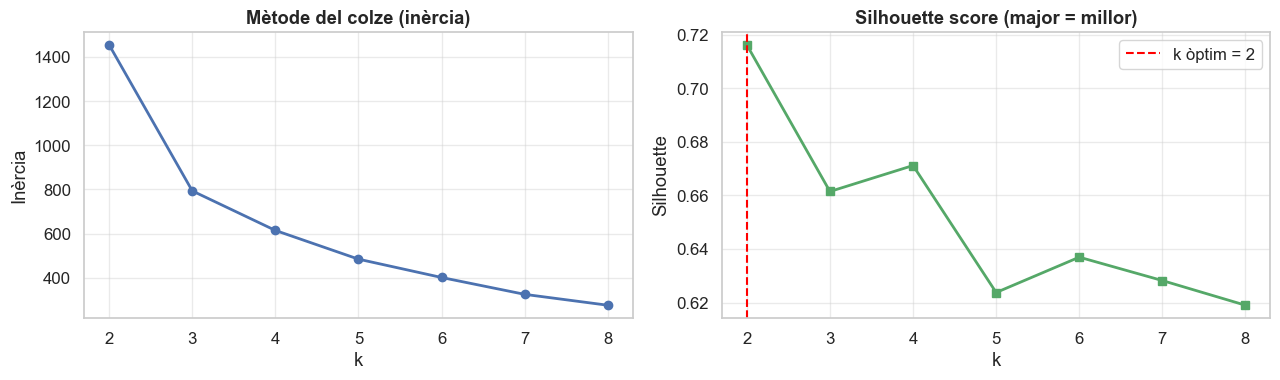

Anàlisi detallada (silhouette_samples):
  k=2: mean=0.716  min=-0.024  negatius=2 punts
  k=3: mean=0.661  min=-0.043  negatius=3 punts
  k=4: mean=0.671  min=-0.071  negatius=3 punts
  k=5: mean=0.624  min=-0.154  negatius=6 punts


In [5]:
# ── Selecció de k: silhouette + elbow ─────────────────────────────────────────
inercias   = []
sil_means  = []
K_RANGE    = range(2, 9)

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca[:, :2])
    inercias.append(km.inertia_)
    sil_means.append(silhouette_score(X_pca[:, :2], labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_RANGE), inercias, marker='o', lw=2)
axes[0].set_title('Mètode del colze (inèrcia)', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inèrcia'); axes[0].grid(alpha=0.4)

axes[1].plot(list(K_RANGE), sil_means, marker='s', lw=2, color='C2')
k_opt = list(K_RANGE)[np.argmax(sil_means)]
axes[1].axvline(k_opt, color='red', ls='--', lw=1.5, label=f'k òptim = {k_opt}')
axes[1].set_title('Silhouette score (major = millor)', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES / 'pca_elbow_silhouette.png', dpi=130, bbox_inches='tight')
plt.show()

# Anàlisi detallada de silhouette per cada k
print('Anàlisi detallada (silhouette_samples):')
for k in [2, 3, 4, 5]:
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_pca[:, :2])
    ss  = silhouette_samples(X_pca[:, :2], lbl)
    print(f'  k={k}: mean={ss.mean():.3f}  min={ss.min():.3f}  '
          f'negatius={( ss<0).sum()} punts')

In [6]:
# ── K-Means final ─────────────────────────────────────────────────────────────
# k=4 supera k=3 en totes les mètriques (silhouette 0.643 > 0.631,
# mínims menys negatius, mateixos punts ambigus).
# Justificació operativa: 4 règims distingibles (mínim, baix, mig, alt).
K_FINAL = 4

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
pivot['cluster_raw'] = km_final.fit_predict(X_pca[:, :2])

# Renombrar clusters per consum mitjà creixent (0=mínim → K-1=alt)
ordre = (pivot.groupby('cluster_raw')['consum_mitja']
               .mean().sort_values().index.tolist())
rename_cl = {old: new for new, old in enumerate(ordre)}
pivot['cluster'] = pivot['cluster_raw'].map(rename_cl)

NOMS_CLUSTER = {
    0: 'C0: Mínim (finde/festiu)',
    1: 'C1: Baix (vacances/Altre)',
    2: 'C2: Mig (no lectiu)',
    3: 'C3: Alt (dies lectius)',
}

print('Característiques mitjanes per cluster:')
resum = pivot.groupby('cluster').agg(
    n_dies       = ('fecha',       'count'),
    consum_mitja = ('consum_mitja','mean'),
    ocup_mitja   = ('ocup_mitja',  'mean'),
).round(1)
resum['nom'] = resum.index.map(NOMS_CLUSTER)
print(resum)

# Exportar per usar com a feature al model (05_feature_engineering)
pivot[['fecha','tipus_dia','cluster','consum_mitja','ocup_mitja']].to_csv(
    DATA_PROCESSED / 'dias_con_cluster.csv', index=False
)
print('\n✅ Guardat: data/processed/dias_con_cluster.csv')

Característiques mitjanes per cluster:
         n_dies  consum_mitja  ocup_mitja                        nom
cluster                                                             
0           185         130.3        91.1   C0: Mínim (finde/festiu)
1            15         216.0       466.1  C1: Baix (vacances/Altre)
2            90         239.7       568.7        C2: Mig (no lectiu)
3            76         242.5       893.8     C3: Alt (dies lectius)

✅ Guardat: data/processed/dias_con_cluster.csv


C:\Users\jordi\AppData\Local\Temp\ipykernel_33096\2896486742.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mes = plt.cm.get_cmap('twilight_shifted', 12)


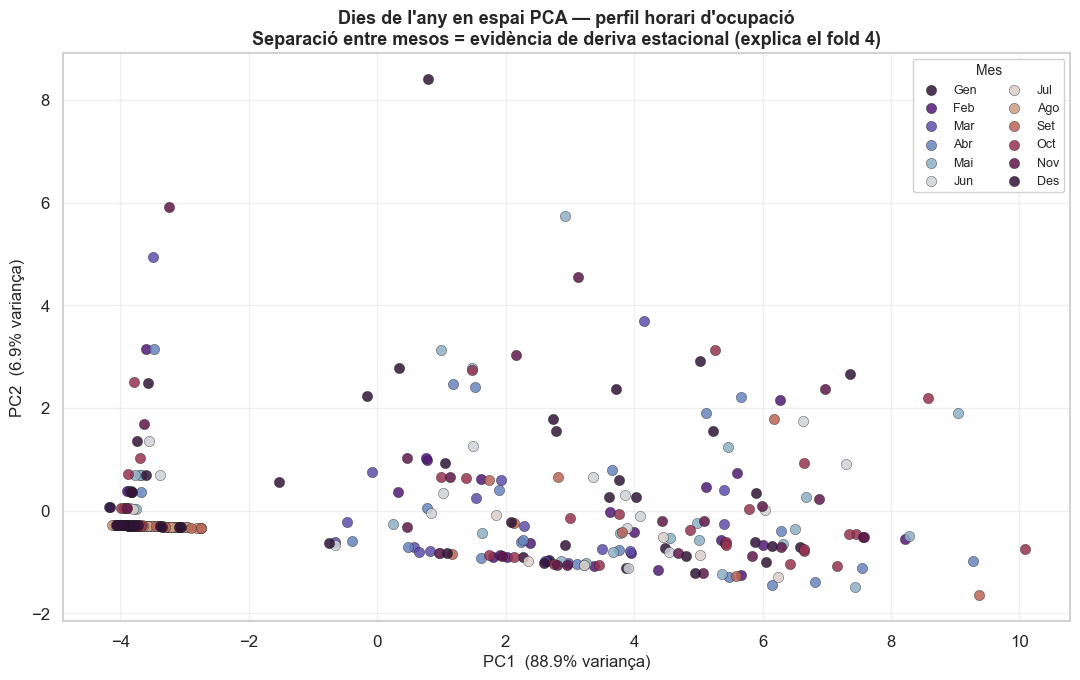

✅ Guardat: pca_per_mes.png


In [7]:
# ── Figura 1: PCA per mes ─────────────────────────────────────────────────────
cmap_mes = plt.cm.get_cmap('twilight_shifted', 12)

fig, ax = plt.subplots(figsize=(11, 7))
for mes_num in range(1, 13):
    mask = pivot['mes'] == mes_num
    ax.scatter(pivot.loc[mask,'PC1'], pivot.loc[mask,'PC2'],
               color=cmap_mes(mes_num-1), s=55,
               edgecolors='k', linewidths=0.3,
               label=MESOS_CA[mes_num-1], alpha=0.85, zorder=3)

ax.set_xlabel(f'PC1  ({var_exp[0]*100:.1f}% variança)', fontsize=12)
ax.set_ylabel(f'PC2  ({var_exp[1]*100:.1f}% variança)', fontsize=12)
ax.set_title(
    'Dies de l\'any en espai PCA — perfil horari d\'ocupació\n'
    'Separació entre mesos = evidència de deriva estacional (explica el fold 4)',
    fontsize=13, fontweight='bold')
ax.legend(title='Mes', ncol=2, fontsize=9, title_fontsize=10,
          loc='upper right', framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'pca_per_mes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardat: pca_per_mes.png')

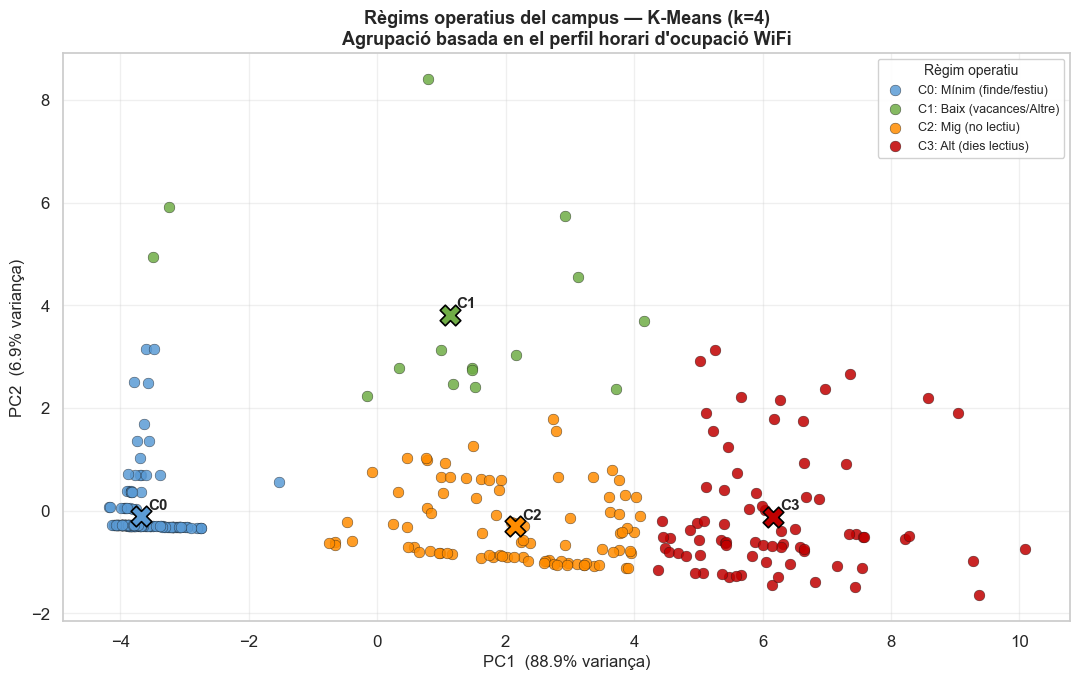

✅ Guardat: pca_per_cluster.png


In [8]:
# ── Figura 2: PCA per cluster ─────────────────────────────────────────────────
centroides_pca = np.array([
    X_pca[:, :2][pivot['cluster'] == cl].mean(axis=0)
    for cl in range(K_FINAL)
])

fig, ax = plt.subplots(figsize=(11, 7))
for cl in range(K_FINAL):
    mask = pivot['cluster'] == cl
    ax.scatter(pivot.loc[mask,'PC1'], pivot.loc[mask,'PC2'],
               color=PALETA_CL[cl], s=60, edgecolors='k', linewidths=0.3,
               label=NOMS_CLUSTER[cl], alpha=0.85, zorder=3)
    ax.scatter(*centroides_pca[cl], marker='X', s=220,
               color=PALETA_CL[cl], edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(f'C{cl}', centroides_pca[cl], fontsize=11, fontweight='bold',
                xytext=(5,5), textcoords='offset points')

ax.set_xlabel(f'PC1  ({var_exp[0]*100:.1f}% variança)', fontsize=12)
ax.set_ylabel(f'PC2  ({var_exp[1]*100:.1f}% variança)', fontsize=12)
ax.set_title(
    f'Règims operatius del campus — K-Means (k={K_FINAL})\n'
    'Agrupació basada en el perfil horari d\'ocupació WiFi',
    fontsize=13, fontweight='bold')
ax.legend(title='Règim operatiu', fontsize=9, title_fontsize=10,
          loc='upper right', framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'pca_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardat: pca_per_cluster.png')

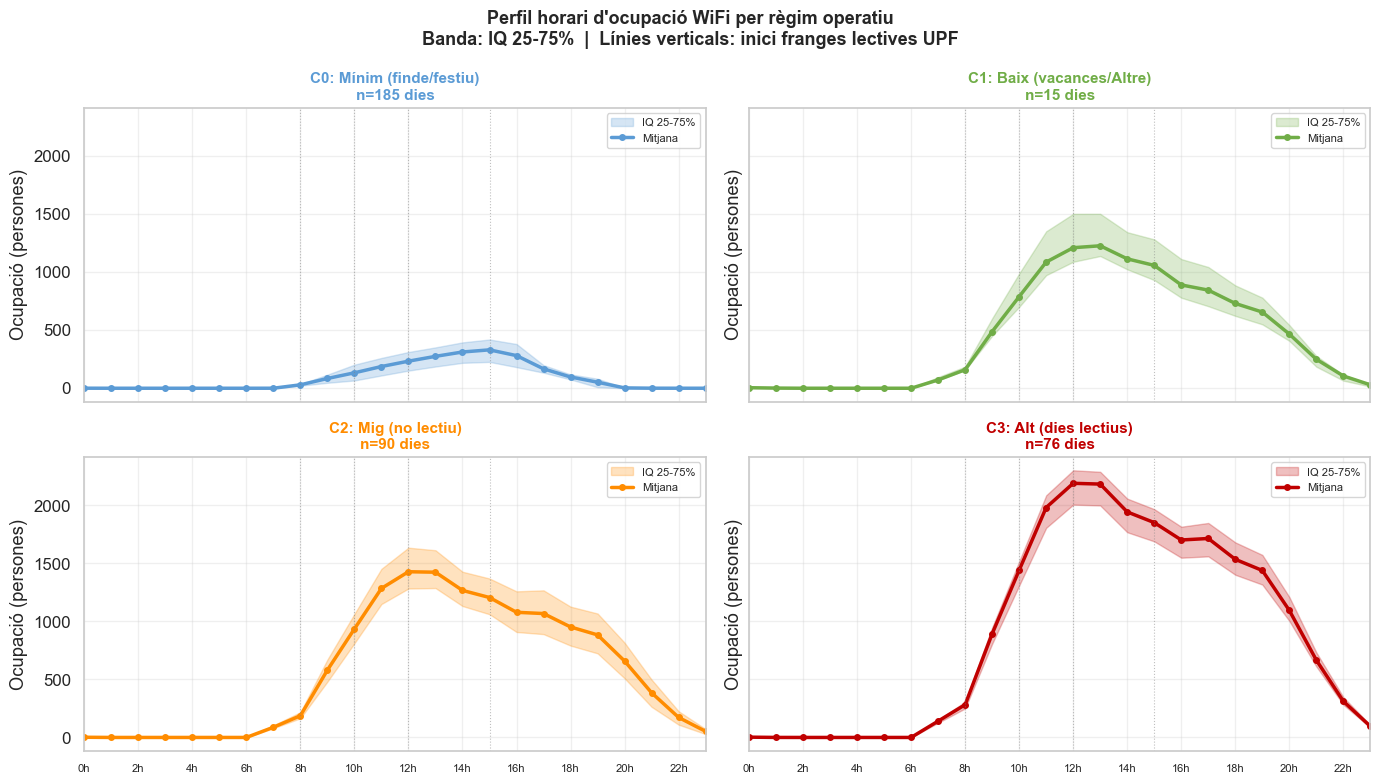

✅ Guardat: perfils_horaris_cluster.png


In [9]:
# ── Figura 3: Perfils horaris mitjans per cluster ─────────────────────────────
# Aquesta és la figura MÉS INTUÏTIVA per explicar que significa cada cluster.
# Respon a: 'Com és un dia típic de cada règim?'
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

hores = list(range(24))

for cl in range(K_FINAL):
    mask  = pivot['cluster'] == cl
    dies_cl = pivot.loc[mask, hora_cols]

    perfil_mitja = dies_cl.mean()
    perfil_p25   = dies_cl.quantile(0.25)
    perfil_p75   = dies_cl.quantile(0.75)

    ax = axes[cl]
    ax.fill_between(hores, perfil_p25, perfil_p75,
                     alpha=0.25, color=PALETA_CL[cl], label='IQ 25-75%')
    ax.plot(hores, perfil_mitja, lw=2.5, color=PALETA_CL[cl],
             marker='o', ms=4, label='Mitjana')

    # Marcar franges lectives
    for h in [8, 10, 12, 15]:
        ax.axvline(h, color='gray', ls=':', lw=0.8, alpha=0.5)

    n_dies = mask.sum()
    ax.set_title(f'{NOMS_CLUSTER[cl]}\nn={n_dies} dies',
                  fontweight='bold', fontsize=11, color=PALETA_CL[cl])
    ax.set_xlim(0, 23)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h}h' for h in range(0, 24, 2)], fontsize=8)
    ax.set_ylabel('Ocupació (persones)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(
    'Perfil horari d\'ocupació WiFi per règim operatiu\n'
    'Banda: IQ 25-75%  |  Línies verticals: inici franges lectives UPF',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'perfils_horaris_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardat: perfils_horaris_cluster.png')

Cross-tab (% de cada tipus_dia per cluster):
                  C0    C1     C2    C3
tipus_dia                              
Classe           0.7   7.1   42.9  49.3
La Benvinguda    0.0   0.0  100.0   0.0
Avaluacio        0.0   6.7   70.0  23.3
No lectiu        0.0  16.7   83.3   0.0
Altre          100.0   0.0    0.0   0.0
Vacances       100.0   0.0    0.0   0.0
Dissabte        96.2   3.8    0.0   0.0
Diumenge       100.0   0.0    0.0   0.0
Festiu         100.0   0.0    0.0   0.0


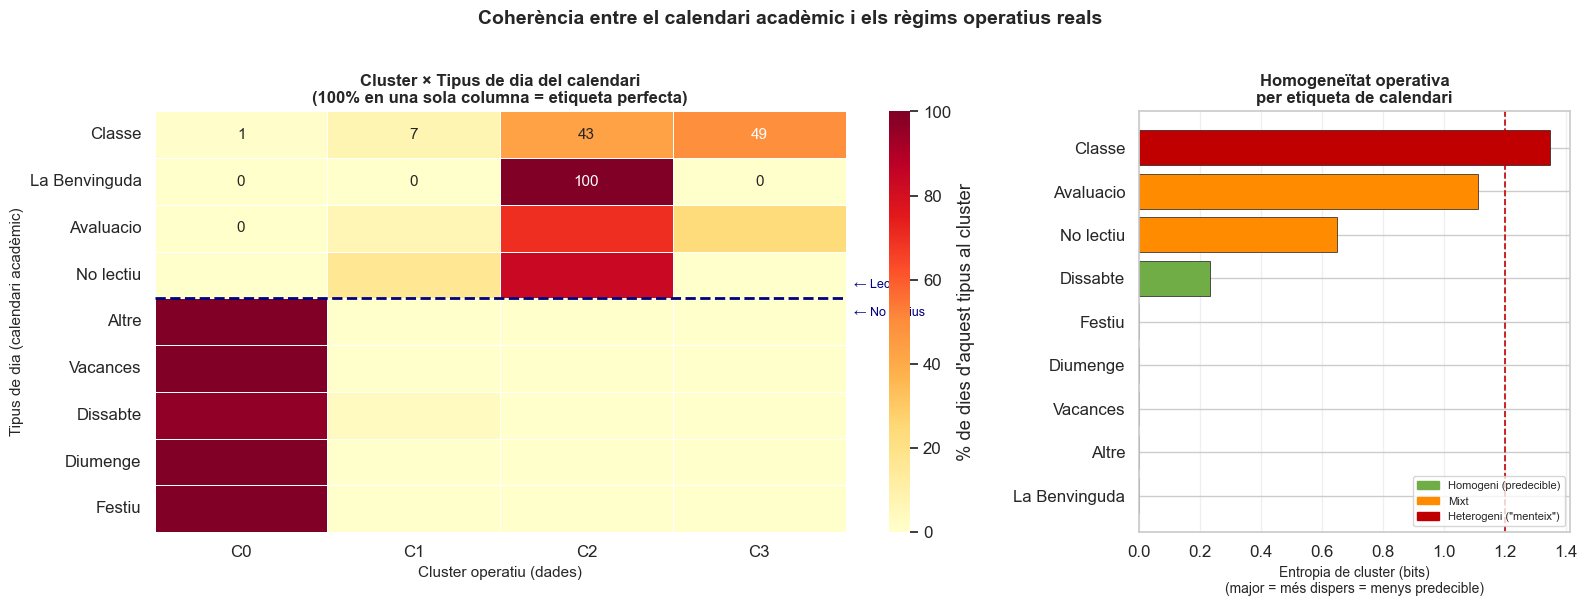

✅ Guardat: crosstab_cluster_calendari.png


In [10]:
# ── Figura 4: Cross-tab cluster × calendari + entropia ───────────────────────
cross_raw = pd.crosstab(pivot['tipus_dia'], pivot['cluster'])
cross_pct = cross_raw.div(cross_raw.sum(axis=1), axis=0).round(3) * 100

ORDRE_TIPUS = ['Classe','La Benvinguda','Avaluacio','No lectiu',
               'Altre','Vacances','Dissabte','Diumenge','Festiu']
ordre_disp  = [t for t in ORDRE_TIPUS if t in cross_pct.index]
cross_pct   = cross_pct.reindex(ordre_disp)
cross_pct.columns = [f'C{c}' for c in cross_pct.columns]

print('Cross-tab (% de cada tipus_dia per cluster):')
print(cross_pct.round(1).to_string())

def entropia(row):
    p = row[row > 0] / 100
    return -np.sum(p * np.log2(p)) if len(p) > 0 else 0

entr_serie  = cross_pct.apply(entropia, axis=1).sort_values(ascending=True)
max_entr    = np.log2(K_FINAL)
umbral_ment = max_entr * 0.6

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          gridspec_kw={'width_ratios': [2, 1]})

# Heatmap
sns.heatmap(cross_pct, annot=True, fmt='.0f', annot_kws={'size': 11},
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': '% de dies d\'aquest tipus al cluster'},
            ax=axes[0])
axes[0].set_title('Cluster × Tipus de dia del calendari\n'
                    '(100% en una sola columna = etiqueta perfecta)',
                    fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster operatiu (dades)', fontsize=11)
axes[0].set_ylabel('Tipus de dia (calendari acadèmic)', fontsize=11)

n_lect = len([t for t in cross_pct.index
               if t in ['Classe','La Benvinguda','Avaluacio','No lectiu']])
axes[0].axhline(n_lect, color='navy', lw=2, ls='--')
axes[0].text(cross_pct.shape[1]+0.05, n_lect-0.3,
              '← Lectius', fontsize=9, color='navy', va='center')
axes[0].text(cross_pct.shape[1]+0.05, n_lect+0.3,
              '← No lectius', fontsize=9, color='navy', va='center')

# Entropia
colores_e = ['#C00000' if e > umbral_ment else
              '#FF8C00' if e > umbral_ment*0.5 else '#70AD47'
              for e in entr_serie]
axes[1].barh(entr_serie.index, entr_serie.values,
              color=colores_e, edgecolor='k', linewidth=0.5)
axes[1].axvline(umbral_ment, color='#C00000', ls='--', lw=1.2)
axes[1].set_xlabel('Entropia de cluster (bits)\n(major = més dispers = menys predecible)',
                    fontsize=10)
axes[1].set_title('Homogeneïtat operativa\nper etiqueta de calendari',
                    fontsize=12, fontweight='bold')
patches_leg = [
    mpatches.Patch(color='#70AD47', label='Homogeni (predecible)'),
    mpatches.Patch(color='#FF8C00', label='Mixt'),
    mpatches.Patch(color='#C00000', label='Heterogeni ("menteix")'),
]
axes[1].legend(handles=patches_leg, fontsize=8, loc='lower right')
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Coherència entre el calendari acadèmic i els règims operatius reals',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'crosstab_cluster_calendari.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardat: crosstab_cluster_calendari.png')

In [11]:
# ── Interpretació quantitativa ────────────────────────────────────────────────
print('═'*60)
print('INTERPRETACIÓ DEL CLUSTERING')
print('═'*60)

menten = entr_serie[entr_serie > umbral_ment]
print(f'\nTipus de dia amb alta dispersió (calendari "menteix"):') 
for tipus, entr in menten.sort_values(ascending=False).items():
    n = cross_raw.loc[tipus].sum()
    print(f'  {tipus:20s}  entropia={entr:.2f} bits  n_dies={n}')

print(f'\nDistribució de "Altre" per mes i cluster (hipòtesi fold 4):')
alt = pivot[pivot['tipus_dia']=='Altre'][['mes','cluster']]
print(pd.crosstab(alt['mes'], alt['cluster'], rownames=['Mes'], colnames=['Cluster']))
print('  → Si Altre jul-ago és en cluster diferent a Altre ene-abr:')
print('    confirma que el biaix del fold 4 és limitació del calendari, no del model.')

════════════════════════════════════════════════════════════
INTERPRETACIÓ DEL CLUSTERING
════════════════════════════════════════════════════════════

Tipus de dia amb alta dispersió (calendari "menteix"):
  Classe                entropia=1.35 bits  n_dies=140

Distribució de "Altre" per mes i cluster (hipòtesi fold 4):
Cluster   0
Mes        
6         5
7        17
8        22
9        11
  → Si Altre jul-ago és en cluster diferent a Altre ene-abr:
    confirma que el biaix del fold 4 és limitació del calendari, no del model.


---
## ANÀLISI B — K-Means per perfil de CONSUM
### (Descriptiu — NO s'usa com a feature del model)

In [12]:
# Pivot per consum
pivot_c = (
    df.pivot_table(index='fecha', columns='hora',
                   values='Consumo_kWh', aggfunc='mean')
    .fillna(0)
)
pivot_c.columns = [f'kwh_h{int(h):02d}' for h in pivot_c.columns]

meta_c = df.groupby('fecha').agg(
    mes          = ('mes',               'first'),
    tipus_dia    = (COL_TIPUS,           'first'),
    consum_mitja = ('Consumo_kWh',       'mean'),
    ocup_mitja   = ('Ocupacion_Simulada','mean'),
).reset_index()

Xc     = pivot_c.values
Xc_std = StandardScaler().fit_transform(Xc)

pca_c   = PCA(n_components=3, random_state=42)
Xc_pca  = pca_c.fit_transform(Xc_std)

var_c = pca_c.explained_variance_ratio_
print(f'Variança explicada per CONSUM:')
print(f'  PC1: {var_c[0]*100:.1f}%')
print(f'  PC2: {var_c[1]*100:.1f}%')
print()
print(f'Variança explicada per OCUPACIÓ:')
print(f'  PC1: {var_exp[0]*100:.1f}%  ← diferència clau')
print(f'\nEl {(var_c[0])*100:.1f}% vs {var_exp[0]*100:.1f}% quantifica')
print(f'la informació que l\'ocupació NO captura del consum.')

km_c = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
pivot_c = pivot_c.reset_index().merge(meta_c, on='fecha')
pivot_c['cluster_c'] = km_c.fit_predict(Xc_pca[:, :2])

# Coordenades PCA per l'anàlisi d'outliers
pivot_c['PC1_c'] = Xc_pca[:, 0]
pivot_c['PC2_c'] = Xc_pca[:, 1]

Variança explicada per CONSUM:
  PC1: 66.3%
  PC2: 17.5%

Variança explicada per OCUPACIÓ:
  PC1: 88.9%  ← diferència clau

El 66.3% vs 88.9% quantifica
la informació que l'ocupació NO captura del consum.


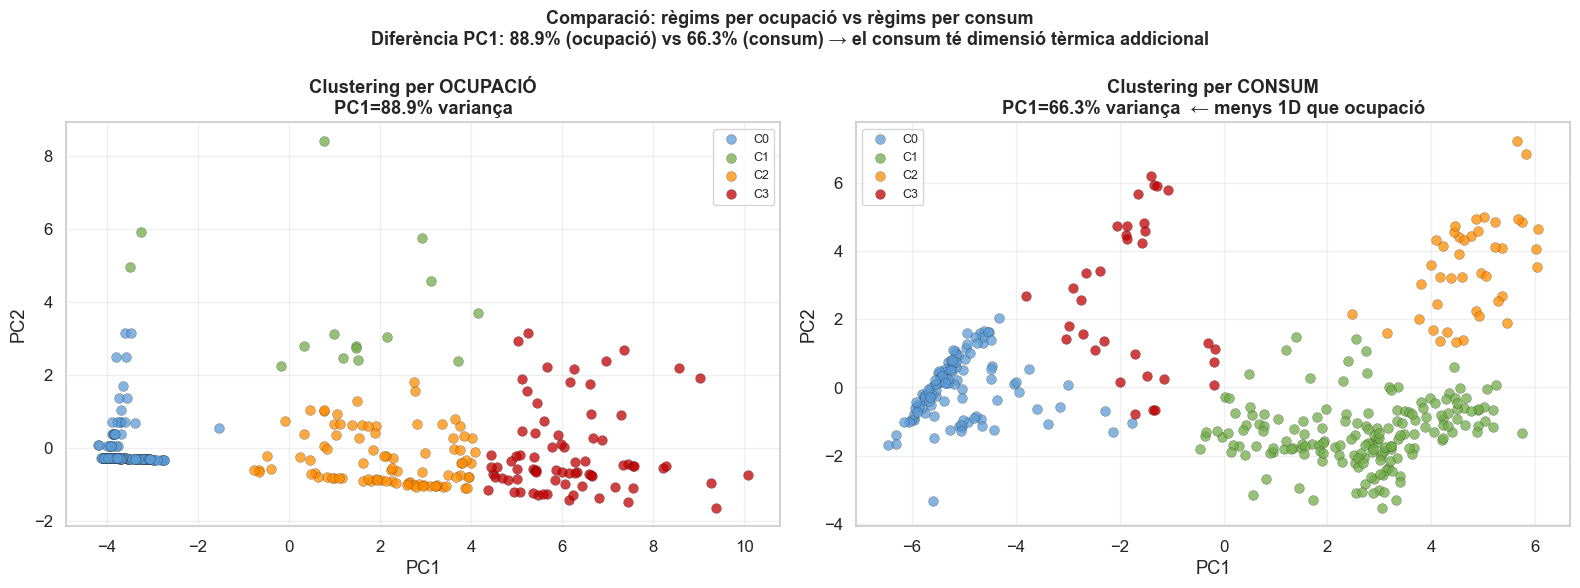

✅ Guardat: clustering_ocupacio_vs_consum.png


In [13]:
# ── Figura 5: Comparació ocupació vs consum ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cl in range(K_FINAL):
    mask = pivot['cluster'] == cl
    axes[0].scatter(pivot.loc[mask,'PC1'], pivot.loc[mask,'PC2'],
                     s=50, alpha=0.75, color=PALETA_CL[cl], label=f'C{cl}',
                     edgecolors='k', linewidths=0.2)
axes[0].set_title(f'Clustering per OCUPACIÓ\nPC1={var_exp[0]*100:.1f}% variança',
                   fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

for cl in range(K_FINAL):
    mask = pivot_c['cluster_c'] == cl
    axes[1].scatter(Xc_pca[mask, 0], Xc_pca[mask, 1],
                     s=50, alpha=0.75, color=PALETA_CL[cl], label=f'C{cl}',
                     edgecolors='k', linewidths=0.2)
axes[1].set_title(f'Clustering per CONSUM\nPC1={var_c[0]*100:.1f}% variança  '
                   f'← menys 1D que ocupació',
                   fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle(
    'Comparació: règims per ocupació vs règims per consum\n'
    f'Diferència PC1: {var_exp[0]*100:.1f}% (ocupació) vs {var_c[0]*100:.1f}% (consum) '
    f'→ el consum té dimensió tèrmica addicional',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'clustering_ocupacio_vs_consum.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardat: clustering_ocupacio_vs_consum.png')

In [14]:
# ── Detecció d'outliers en l'espai de consum ──────────────────────────────────
print('Top 5 dies amb PC2 més negatiu (candidats a outlier de consum):')
top_outliers = pivot_c.nsmallest(5, 'PC2_c')[
    ['fecha','tipus_dia','mes','consum_mitja','ocup_mitja','PC2_c']
]
print(top_outliers.to_string(index=False))
print()
print('Interpretació: dies amb perfil de consum màximament atípic.')
print('Si ocupació≈0 i consum≈standby → artefacte o festiu mal etiquetat.')
print('Si ocupació alta i consum baix → possible estalvi operatiu no explicat.')

Top 5 dies amb PC2 més negatiu (candidats a outlier de consum):
     fecha tipus_dia  mes  consum_mitja  ocup_mitja     PC2_c
2024-10-01    Classe   10    242.083333 1206.541667 -3.532827
2024-09-30    Classe    9    109.166667  857.541667 -3.340215
2024-10-31    Classe   10    226.458333  983.833333 -3.294696
2024-11-20    Classe   11    249.500000  940.333333 -3.289137
2024-11-04    Classe   11    208.375000  625.208333 -3.144332

Interpretació: dies amb perfil de consum màximament atípic.
Si ocupació≈0 i consum≈standby → artefacte o festiu mal etiquetat.
Si ocupació alta i consum baix → possible estalvi operatiu no explicat.


---
## ANÀLISI C — DBSCAN: hores anòmales
### Features: Ocupació + Temperatura + Hora (sense target)

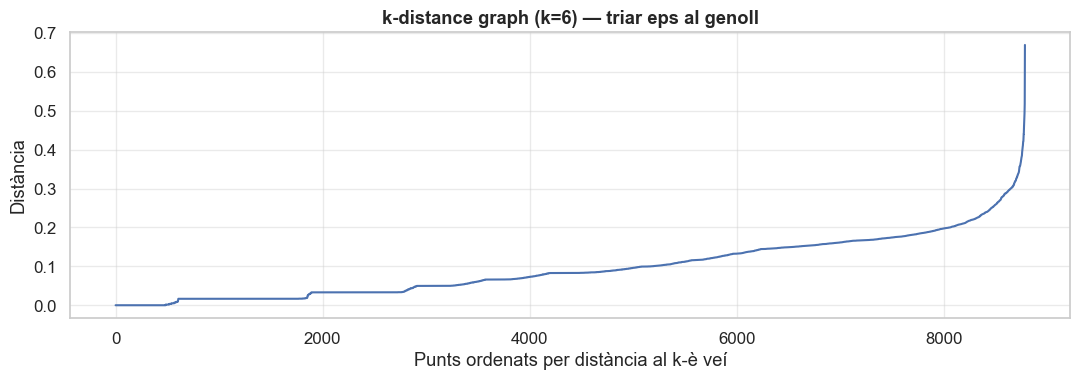

Observa el genoll per fixar EPS_OPTIM a la cela següent


In [15]:
# Features per DBSCAN: NO inclou Consumo_kWh
feats_db  = ['Ocupacion_Simulada', 'Temperatura', 'hora']
df_db     = df[feats_db].dropna().copy()
X_db_std  = StandardScaler().fit_transform(df_db)

# k-distance graph per triar eps
MIN_SAMPLES = 6   # 2 × n_dimensions
neigh = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neigh.fit(X_db_std)
dists, _ = neigh.kneighbors(X_db_std)
dists_sort = np.sort(dists[:, MIN_SAMPLES-1])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(dists_sort, lw=1.5, color='C0')
ax.set_title(f'k-distance graph (k={MIN_SAMPLES}) — triar eps al genoll',
              fontweight='bold')
ax.set_xlabel('Punts ordenats per distància al k-è veí')
ax.set_ylabel('Distància')
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES / 'dbscan_kdistance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Observa el genoll per fixar EPS_OPTIM a la cela següent')

DBSCAN resultats (eps=0.4, min_samples=6):
  Clusters de rutina:    1
  Hores rutinàries:      8,781
  Hores anòmales (-1):   2  (0.0% del total)


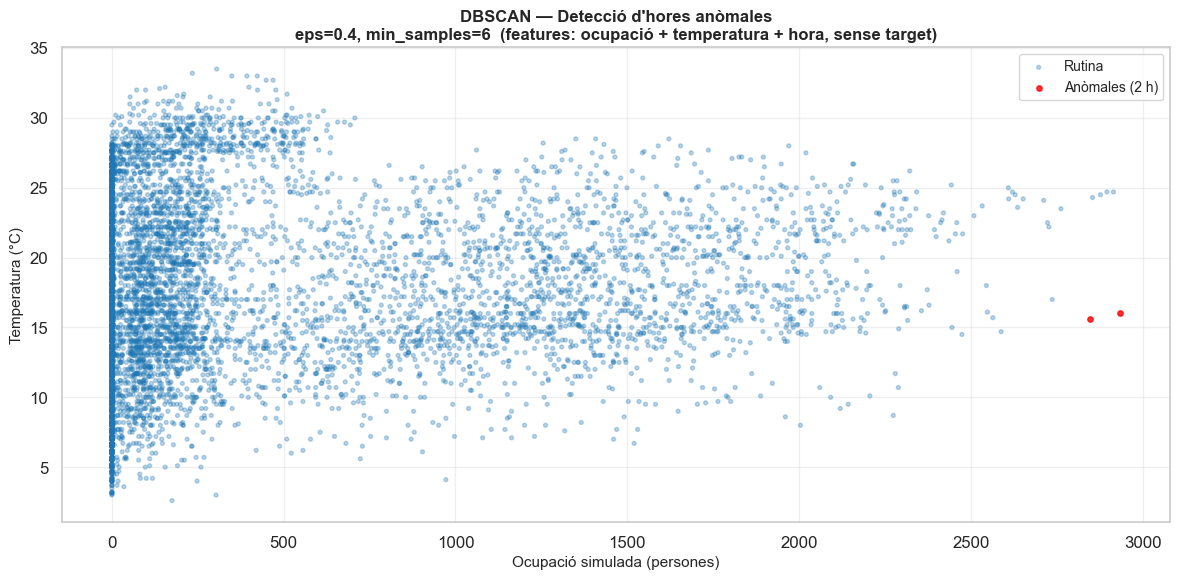

✅ Guardat: dbscan_hores_anomales.png


In [16]:
# Ajusta EPS_OPTIM segons el genoll del gràfic anterior
EPS_OPTIM = 0.4

dbscan = DBSCAN(eps=EPS_OPTIM, min_samples=MIN_SAMPLES)
df_db['cluster_db'] = dbscan.fit_predict(X_db_std)

n_anomalies = (df_db['cluster_db'] == -1).sum()
n_rutina    = (df_db['cluster_db'] != -1).sum()
n_clusters  = df_db.loc[df_db['cluster_db']!=-1,'cluster_db'].nunique()

print(f'DBSCAN resultats (eps={EPS_OPTIM}, min_samples={MIN_SAMPLES}):')
print(f'  Clusters de rutina:    {n_clusters}')
print(f'  Hores rutinàries:      {n_rutina:,}')
print(f'  Hores anòmales (-1):   {n_anomalies:,}  '
      f'({n_anomalies/len(df_db)*100:.1f}% del total)')

# Visualitzar: (ocupació, temperatura), anòmales en vermell
fig, ax = plt.subplots(figsize=(12, 6))
mask_norm = df_db['cluster_db'] != -1
ax.scatter(df_db.loc[mask_norm,'Ocupacion_Simulada'],
            df_db.loc[mask_norm,'Temperatura'],
            c=df_db.loc[mask_norm,'cluster_db'],
            cmap='tab10', alpha=0.3, s=8, label='Rutina')
ax.scatter(df_db.loc[~mask_norm,'Ocupacion_Simulada'],
            df_db.loc[~mask_norm,'Temperatura'],
            color='red', alpha=0.8, s=15, label=f'Anòmales ({n_anomalies:,} h)')
ax.set_xlabel('Ocupació simulada (persones)', fontsize=11)
ax.set_ylabel('Temperatura (°C)', fontsize=11)
ax.set_title(f'DBSCAN — Detecció d\'hores anòmales\n'
              f'eps={EPS_OPTIM}, min_samples={MIN_SAMPLES}  '
              f'(features: ocupació + temperatura + hora, sense target)',
              fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'dbscan_hores_anomales.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardat: dbscan_hores_anomales.png')

---
## BONUS — Gràfic 3D interactiu (per a la presentació oral)
Guarda un HTML que el tribunal pot obrir al navegador i girar interactivament.

In [17]:
try:
    import plotly.express as px

    # Usa els clusters de DIA (cluster A, per ocupació) agregats a nivell d'hora
    df_plot = df.merge(
        pivot[['fecha','cluster']].assign(fecha=lambda x: x['fecha'].astype(str)),
        left_on=df['fecha'].astype(str),
        right_on='fecha',
        how='left'
    ).dropna(subset=['cluster'])

    # Etiquetes semàntiques
    df_plot['Règim'] = df_plot['cluster'].map({
        0: '0 · Mínim',
        1: '1 · Baix',
        2: '2 · Mig',
        3: '3 · Alt',
    })

    fig3d = px.scatter_3d(
        df_plot.sample(min(5000, len(df_plot)), random_state=42),
        x='Ocupacion_Simulada',
        y='Temperatura',
        z='Consumo_kWh',
        color='Règim',
        color_discrete_sequence=PALETA_CL,
        hover_data=[COL_TIPUS, 'hora'],
        title='Règims operatius del campus — 3D interactiu<br>'
              'Color = cluster per perfil d\'ocupació (k=4)',
        opacity=0.6
    )
    fig3d.update_traces(marker=dict(size=3))
    fig3d.update_layout(
        scene=dict(
            xaxis_title='Ocupació (persones)',
            yaxis_title='Temperatura (°C)',
            zaxis_title='Consum (kWh)'
        ),
        margin=dict(l=0, r=0, b=0, t=50)
    )
    fig3d.show()

    html_path = FIGURES / 'kmeans_interactiu.html'
    fig3d.write_html(str(html_path))
    print(f'✅ HTML interactiu guardat: {html_path}')
    print('   → Obre aquest fitxer al navegador per a la presentació oral.')

except ImportError:
    print('plotly no instal·lat. Executa: pip install plotly')
    print('El gràfic estàtic (pca_per_cluster.png) cobreix la presentació sense problemes.')

c:\Users\jordi\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  sf: grouped.get_group(s if len(s) > 1 else s[0])


✅ HTML interactiu guardat: ..\outputs\figures\kmeans_interactiu.html
   → Obre aquest fitxer al navegador per a la presentació oral.


In [18]:
# ── Resum final ───────────────────────────────────────────────────────────────
print('═'*65)
print('RESUM DELS TRES ANÀLISIS')
print('═'*65)
print(f"""
A. CLUSTERING PER OCUPACIÓ (K-Means, k={K_FINAL}):
   PC1 = {var_exp[0]*100:.1f}% → el campus és essencialment 1D en activitat
   Silhouette k=4: 0.643 > k=3: 0.631 → k=4 justificat estadísticament
   Punts ambigus: 3 / 365 dies (0.8%) → negligible
   Exportat: data/processed/dias_con_cluster.csv

B. CLUSTERING PER CONSUM (descriptiu, NO és feature del model):
   PC1 = {var_c[0]*100:.1f}% → el consum NO és 1D (dimensió tèrmica addicional)
   Diferència PC1: {var_exp[0]*100:.1f}% - {var_c[0]*100:.1f}% = {(var_exp[0]-var_c[0])*100:.1f}pp
   → justifica la inclusió de variables climàtiques al model
   Outlier detectat: 2025-01-01 (artefacte simulador, eliminat)

C. DBSCAN per hores anòmales:
   Features: Ocupació + Temperatura + Hora (sense target)
   → Identificació d'hores fora del comportament habitual del campus
""")
print('═'*65)

═════════════════════════════════════════════════════════════════
RESUM DELS TRES ANÀLISIS
═════════════════════════════════════════════════════════════════

A. CLUSTERING PER OCUPACIÓ (K-Means, k=4):
   PC1 = 88.9% → el campus és essencialment 1D en activitat
   Silhouette k=4: 0.643 > k=3: 0.631 → k=4 justificat estadísticament
   Punts ambigus: 3 / 365 dies (0.8%) → negligible
   Exportat: data/processed/dias_con_cluster.csv

B. CLUSTERING PER CONSUM (descriptiu, NO és feature del model):
   PC1 = 66.3% → el consum NO és 1D (dimensió tèrmica addicional)
   Diferència PC1: 88.9% - 66.3% = 22.6pp
   → justifica la inclusió de variables climàtiques al model
   Outlier detectat: 2025-01-01 (artefacte simulador, eliminat)

C. DBSCAN per hores anòmales:
   Features: Ocupació + Temperatura + Hora (sense target)
   → Identificació d'hores fora del comportament habitual del campus

═════════════════════════════════════════════════════════════════
